In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import datetime
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose

In [5]:
ticker='^GSPC'
start_date = datetime.datetime(2018,3,28)
end_date = datetime.datetime(2024,3,28)
SP=yf.download(ticker, start=start_date, end=end_date,interval='1mo')['Adj Close']

[*********************100%%**********************]  1 of 1 completed


In [6]:
SP.sample(10)

Date
2022-07-01    4130.290039
2021-03-01    3972.889893
2019-12-01    3230.780029
2022-06-01    3785.379883
2021-07-01    4395.259766
2024-01-01    4845.649902
2020-08-01    3500.310059
2019-11-01    3140.979980
2020-03-01    2584.590088
2020-09-01    3363.000000
Name: Adj Close, dtype: float64

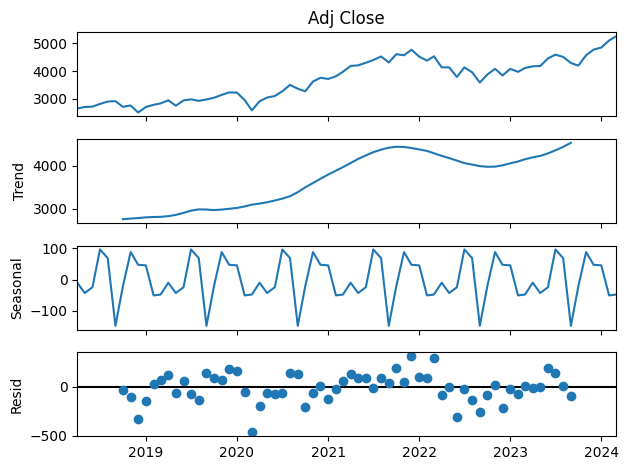

In [7]:
seasonal_decompose(SP, period=12).plot()
plt.show()

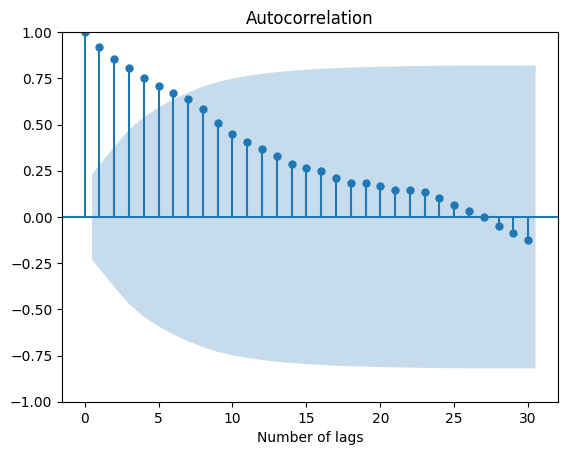

In [8]:
#Time dependance - Autocorrelation Function
sm.graphics.tsa.plot_acf(SP, lags=30)
plt.xlabel('Number of lags')
plt.show()

In [10]:
#Sources of auto correlations:

#The primary source of autocorrelation is “carryover,” meaning that the preceding observation has an impact on the current one.
#Model mis specification.
#Measurement error, which is basically the difference between observed and actual values.
#Dropping a variable, which has an explanatory power.

In [11]:
#PACF-PACF provides information on the correlation between the current value of a time series and its lagged values, 
#controlling for the other correlations.

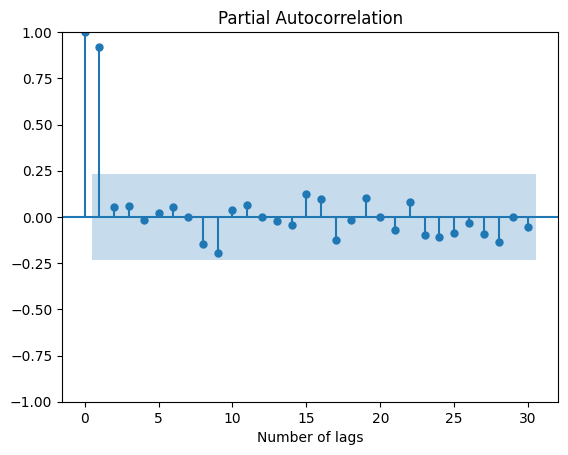

In [12]:
sm.graphics.tsa.plot_pacf(SP, lags=30)
plt.xlabel('Number of lags')
plt.show()

In [13]:
#in interpreting the PACF, we focus on the spikes outside the dark region representing confidence interval. 
#Figure exhibits some spikes at different lags, but lag 10 is outside the confidence interval. 
#So it may be wise to select a model with 10 lags to include all the lags up to lag 10.

In [14]:
#SEASONALITY
from fredapi import Fred
fred=Fred(api_key='60a4866a14837767d36acd60c0e6ff79')

In [15]:
energy=fred.get_series("CAPUTLG2211A2S",
                    observation_start='2014-03-31',
                    observation_end='2024-03-31')

In [16]:
energy.head()

2014-03-01    83.1864
2014-04-01    80.8237
2014-05-01    80.6222
2014-06-01    79.2233
2014-07-01    77.4483
dtype: float64

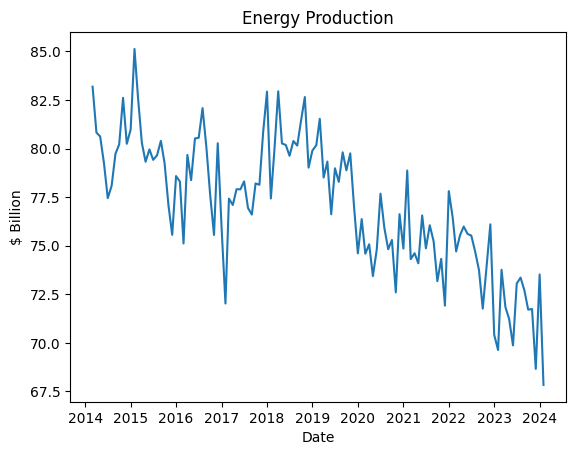

In [17]:
plt.plot(energy)
plt.title('Energy Production')
plt.xlabel('Date')
plt.ylabel('$ Billion')
plt.show()

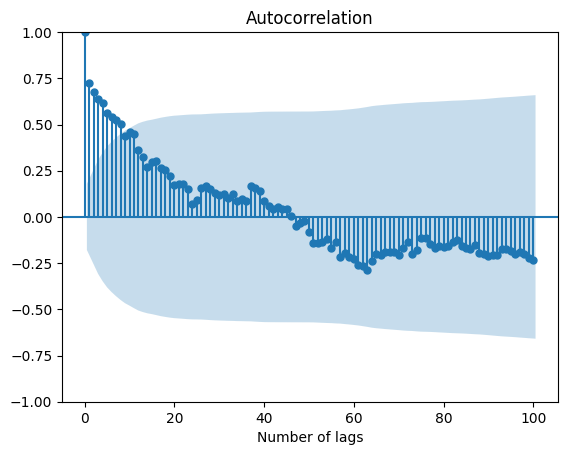

In [20]:
sm.graphics.tsa.plot_acf(energy, lags=100)
plt.xlabel('Number of lags')
plt.show()

In [27]:
#Test for stationarity - Augmented Dickey-Fuller Test
#Null hypothesis: the time series is non-stationary.
#Alternative hypothesis: the time series is stationary.

result=adfuller(SP)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -0.482039
p-value: 0.895474
Critical Values:
	1%: -3.526
	5%: -2.903
	10%: -2.589


In [38]:
#make series Stationary - subtracting the current value of the series from its first lagged value

In [39]:
diff_SP=SP.diff().dropna()

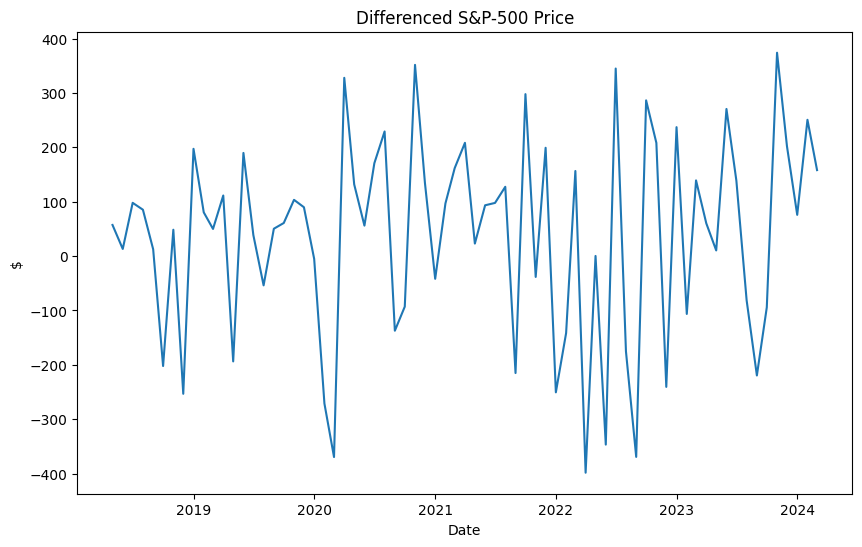

In [40]:
plt.figure(figsize=(10, 6))
plt.plot(diff_SP)
plt.title('Differenced S&P-500 Price')
plt.ylabel('$')
plt.xlabel('Date')
plt.show()

Text(0.5, 0, 'Number of lags')

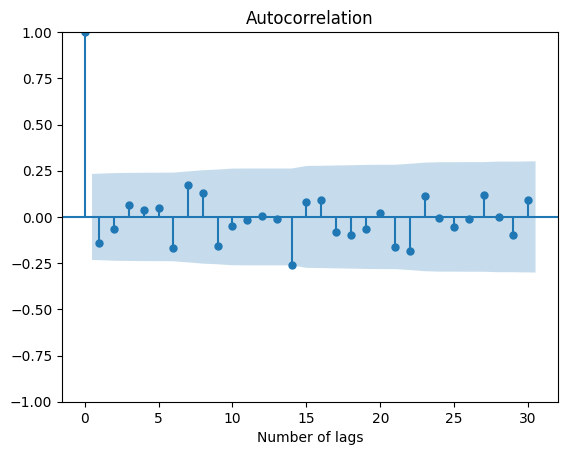

In [41]:
sm.graphics.tsa.plot_acf(diff_SP.dropna(), lags=30)
plt.xlabel('Number of lags')

In [42]:
result2=adfuller(diff_SP)
print('ADF Statistic: %f' % result2[0])
print('p-value: %f' % result2[1])
print('Critical Values:')
for key, value in result2[4].items():
    print('\t%s: %.3f' % (key, value))



ADF Statistic: -9.492143
p-value: 0.000000
Critical Values:
	1%: -3.527
	5%: -2.904
	10%: -2.589


In [ ]:
#trend is not the only indicator of nonstationarity. Seasonality is another source of it, 
#and now we are about to learn a method to deal with it

In [43]:
seasonal_index = energy.resample('Q').mean()

In [45]:
dates = energy.index.year.unique() # get unique years
deseasonalized = []
for i in dates:
        for j in range(1, 13):
            deseasonalized.append((energy[str(i)][energy[str(i)].index.month==j]))
concat_deseasonalized = np.concatenate(deseasonalized)

In [47]:
deseason_energy = []
for i,s in zip(range(0, len(energy), 3), range(len(seasonal_index))):
        
        deseason_energy.append(concat_deseasonalized[i:i+3] / seasonal_index.iloc[s])
        
concat_deseason_energy = np.concatenate(deseason_energy)
deseason_energy = pd.DataFrame(concat_deseason_energy,index=energy.index)
deseason_energy.columns = ['Deaseasonalized Energy']

deseason_energy.head()

,Deaseasonalized Energy
2014-03-01,1.000000
2014-04-01,0.971598
2014-05-01,0.969175
2014-06-01,0.987538
2014-07-01,0.965412


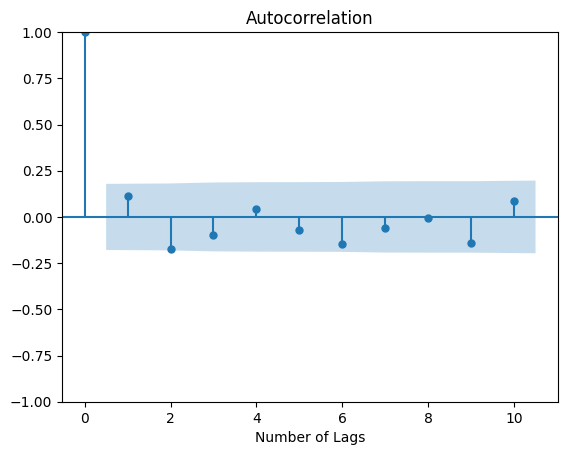

In [48]:
sm.graphics.tsa.plot_acf(deseason_energy, lags=10)
plt.xlabel('Number of Lags')
plt.show()

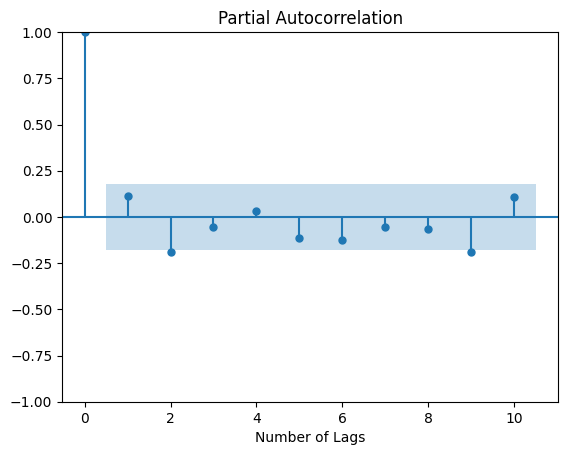

In [49]:
sm.graphics.tsa.plot_pacf(deseason_energy, lags=10)
plt.xlabel('Number of Lags')
plt.show()

In [50]:
#Moving Average Model

In [60]:
ticker=['GOOGL','AMZN']
start=datetime.datetime(2021,3,28)
end=datetime.datetime(2024,3,28)
stock_prices=yf.download(ticker, start=start, end=end,interval='1d')['Close']

[*********************100%%**********************]  2 of 2 completed


In [61]:
#As a first step, we dropped the missing values and checked if the data is stationary, 
#and it turns out neither Apple’s nor Microsoft’s stock prices have a stationary structure as expected. 
#Thus, taking the first difference to make these data stationary and 
#splitting the data as train and test are the steps to take at this point.

In [62]:
stock_prices=stock_prices.dropna()

In [63]:
for i in ticker:
    result=adfuller(stock_prices[i])
    print(f'{i} ADF Statistic: {result[0]}')
    print(f'{i} p-value: {result[1]}')
    print(f'{i} Critical Values:')
    for key, value in result[4].items():
        print(f'\t{key}: {value:.3f}')

GOOGL ADF Statistic: -1.707915866104944
GOOGL p-value: 0.42703866886332686
GOOGL Critical Values:
	1%: -3.439
	5%: -2.865
	10%: -2.569
AMZN ADF Statistic: -1.201654382660666
AMZN p-value: 0.672883633680789
AMZN Critical Values:
	1%: -3.439
	5%: -2.865
	10%: -2.569


In [64]:
diff_stock_prices=stock_prices.diff().dropna()

In [74]:
#Splitting data as 95% and 5%
#Assigning 95% of the Google stock price data to the train set
#Assigning 5% of the Google stock price data to the test set
#Assigning 95% of the Amazon stock price data to the train set
#Assigning 5% of the Amazon stock price data to the test set


split = int(len(diff_stock_prices['GOOGL'].values) * 0.95) 
split_=int(len(diff_stock_prices['AMZN'].values) * 0.95)

diff_train_googl = diff_stock_prices['GOOGL'].iloc[:split]
diff_test_googl = diff_stock_prices['GOOGL'].iloc[split:]
diff_train_amzn = diff_stock_prices['AMZN'].iloc[:split_]
diff_test_amzn = diff_stock_prices['AMZN'].iloc[split_:]

In [75]:
#Saving the data for future use
diff_train_googl.to_csv('diff_train_googl.csv')
diff_test_googl.to_csv('diff_test_googl.csv')
diff_train_amzn.to_csv('diff_train_amzn.csv')
diff_test_amzn.to_csv('diff_test_amzn.csv')

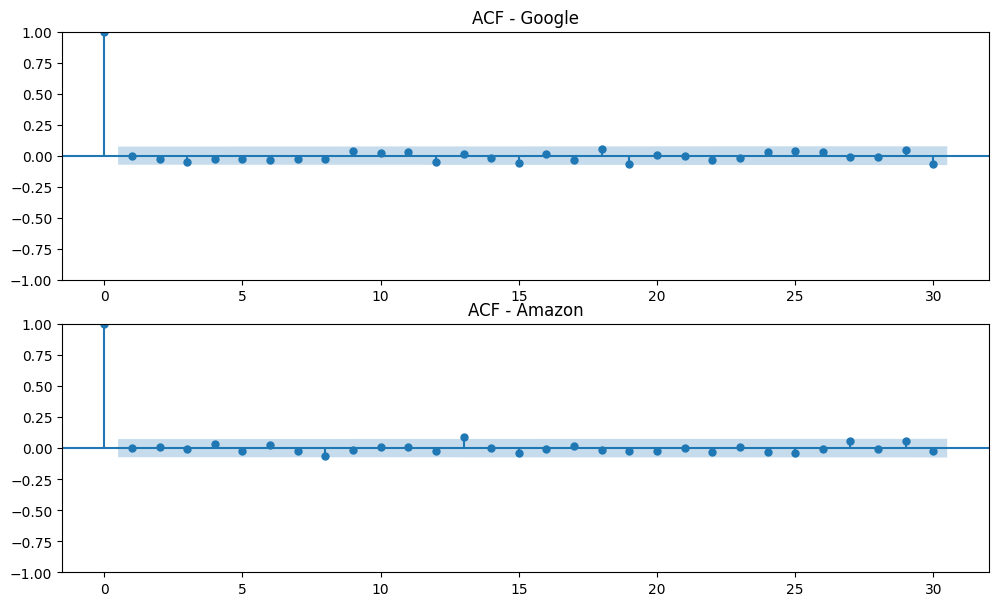

In [76]:
fig, ax = plt.subplots(2, 1, figsize=(10, 6))
plt.tight_layout()
sm.graphics.tsa.plot_acf(diff_train_googl,lags=30,ax=ax[0], title='ACF - Google')
sm.graphics.tsa.plot_acf(diff_train_amzn,lags=30,ax=ax[1], title='ACF - Amazon')
plt.show()

In [ ]:
#there are significant spikes at some lags and, therefore, we’ll choose lag 12 
#for the short MA model and 18 for the long MA for Google.

In [77]:
short_moving_average_googl = diff_train_googl.rolling(window=12).mean()
long_moving_average_googl = diff_train_googl.rolling(window=18).mean() 

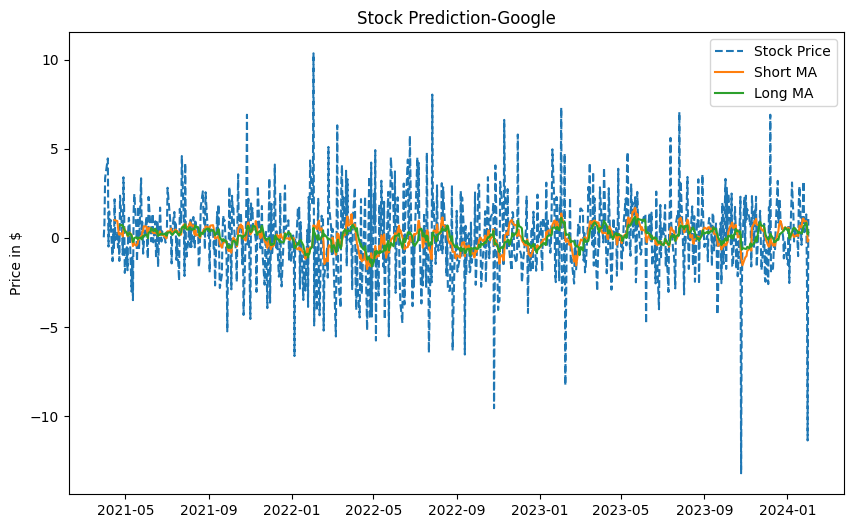

In [80]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(diff_train_googl.loc[start:end].index,diff_train_googl.loc[start:end],label='Stock Price', linestyle='--')
ax.plot(short_moving_average_googl.loc[start:end].index,short_moving_average_googl.loc[start:end],label = 'Short MA', linestyle='solid')
ax.plot(long_moving_average_googl.loc[start:end].index,long_moving_average_googl.loc[start:end],label = 'Long MA', linestyle='solid')
ax.legend(loc='best')
ax.set_ylabel('Price in $')
ax.set_title('Stock Prediction-Google')
plt.show()

In [82]:
short_moving_average_amzn = diff_train_amzn.rolling(window=13).mean()
long_moving_average_amzn = diff_train_amzn.rolling(window=27).mean() 

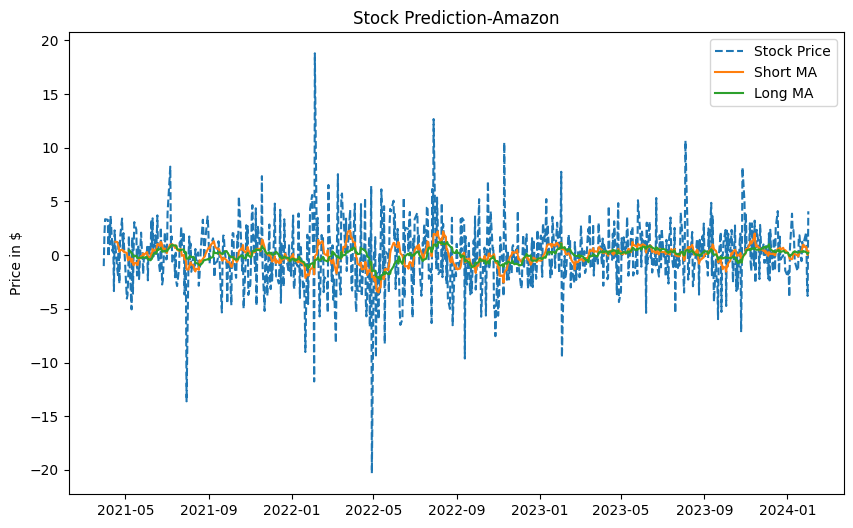

In [83]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(diff_train_amzn.loc[start:end].index,diff_train_amzn.loc[start:end],label='Stock Price', linestyle='--')
ax.plot(short_moving_average_amzn.loc[start:end].index,short_moving_average_amzn.loc[start:end],label = 'Short MA', linestyle='solid')
ax.plot(long_moving_average_amzn.loc[start:end].index,long_moving_average_amzn.loc[start:end],label = 'Long MA', linestyle='solid')
ax.legend(loc='best')
ax.set_ylabel('Price in $')
ax.set_title('Stock Prediction-Amazon')
plt.show()

In [ ]:
#Autoregressive Model
